Dataset Shape: (541, 12)
   Unnamed: 0            Model        Colour  Memory  RAM  Battery_  \
0           0  Infinix SMART 7   Night Black      64    4      6000   
1           1  Infinix SMART 7    Azure Blue      64    4      6000   
2           2     MOTOROLA G32  Mineral Gray     128    8      5000   
3           3         POCO C50    Royal Blue      32    2      5000   
4           4  Infinix HOT 30i      Marigold     128    8      5000   

  Rear Camera Front Camera  AI Lens  Mobile Height  \
0        13MP          5MP        1          16.76   
1        13MP          5MP        1          16.76   
2        50MP         16MP        0          16.64   
3         8MP          5MP        0          16.56   
4        50MP          5MP        1          16.76   

                   Processor_  Prize  
0  Unisoc Spreadtrum SC9863A1   7299  
1  Unisoc Spreadtrum SC9863A1   7299  
2     Qualcomm Snapdragon 680  11999  
3          Mediatek Helio A22   5649  
4                         G3

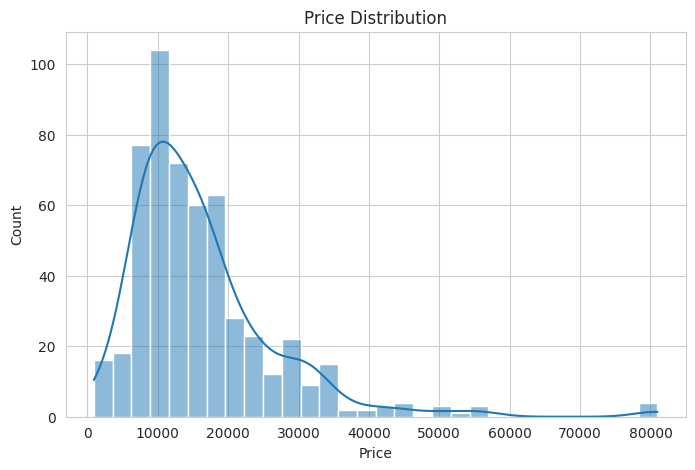

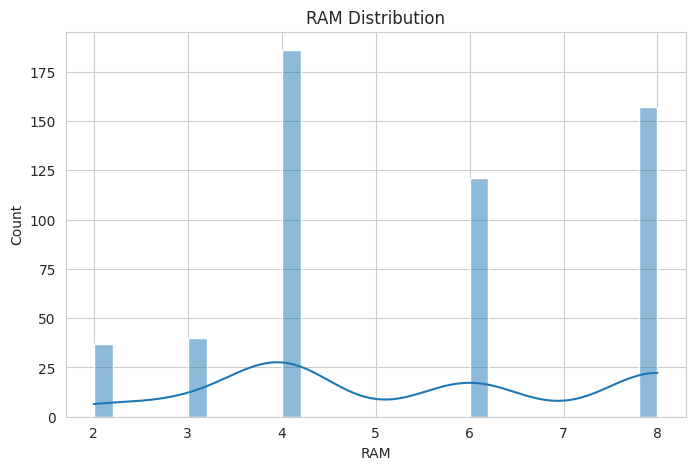

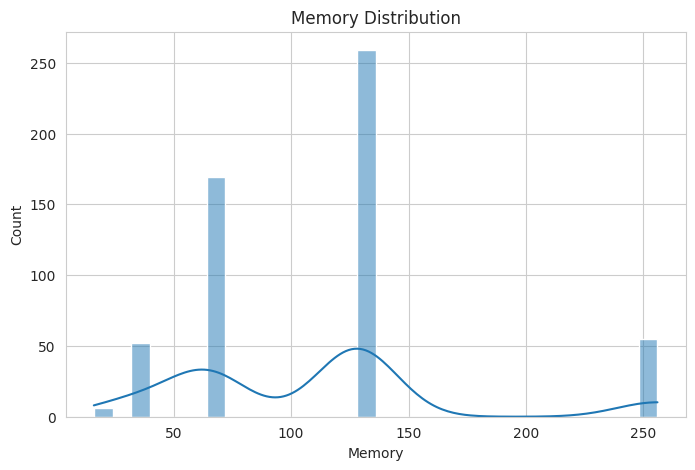

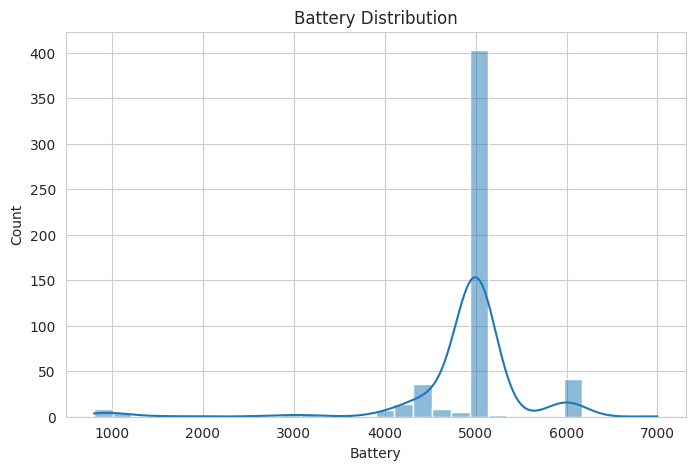

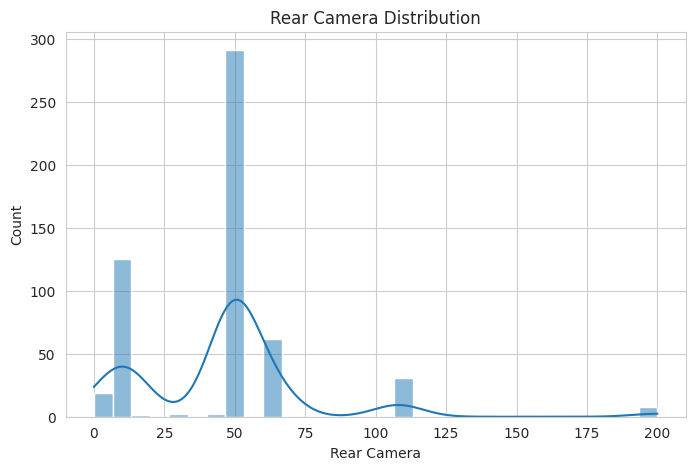

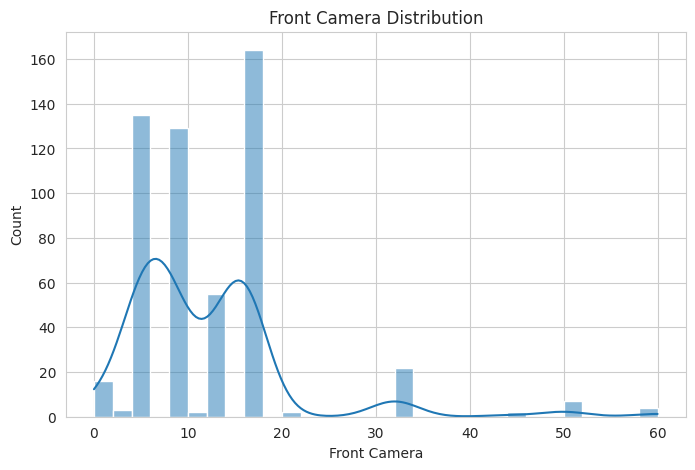

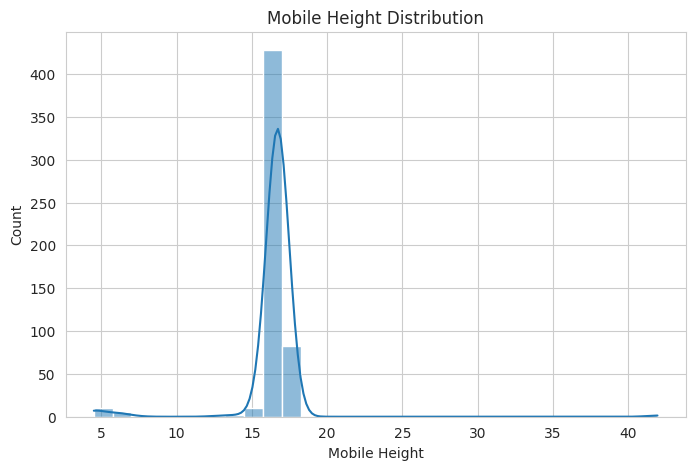

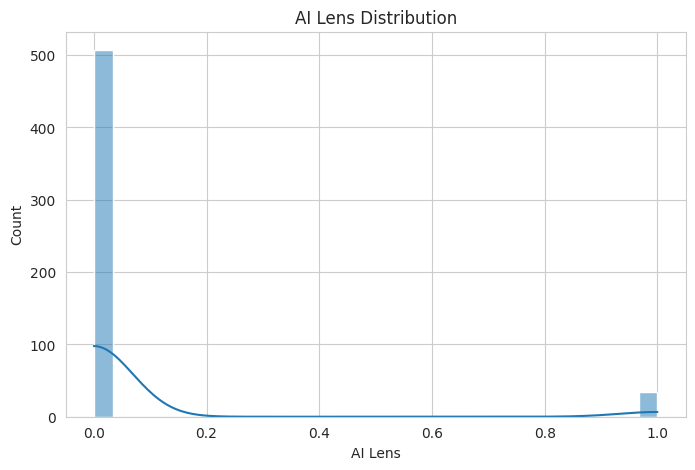

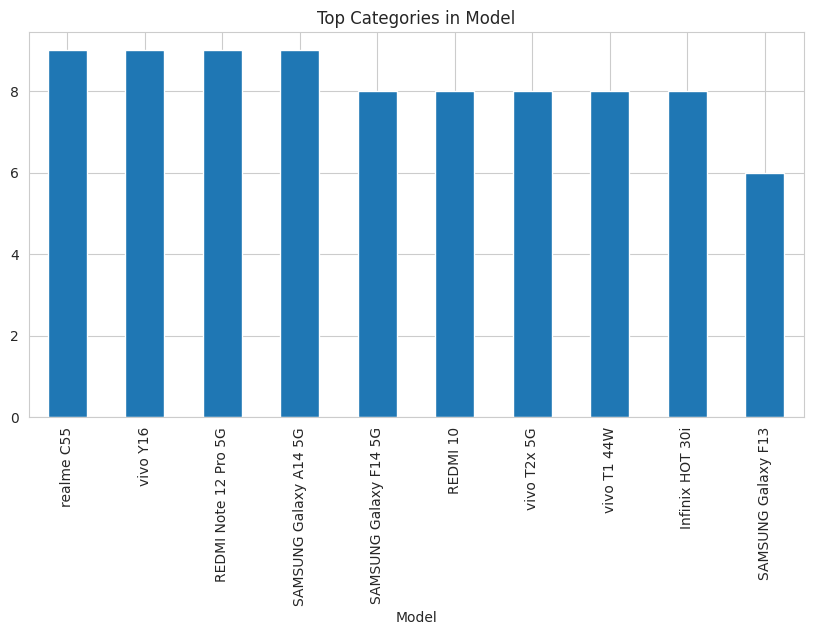

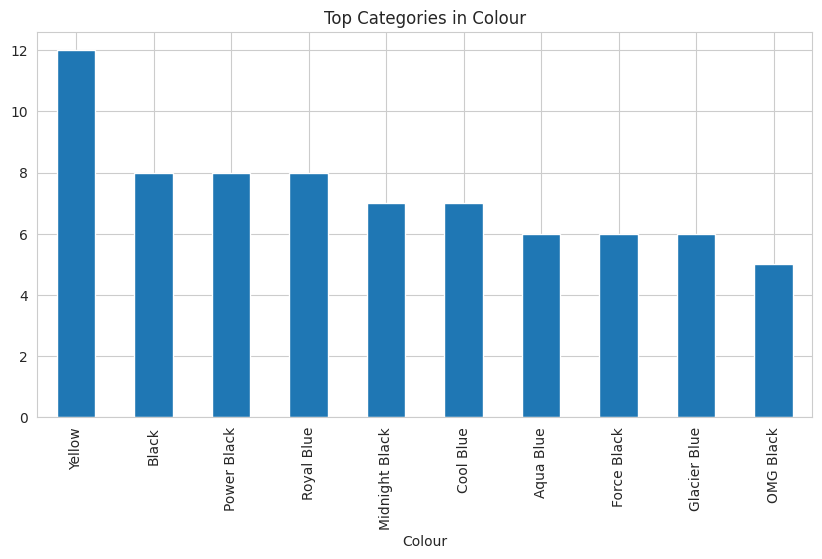

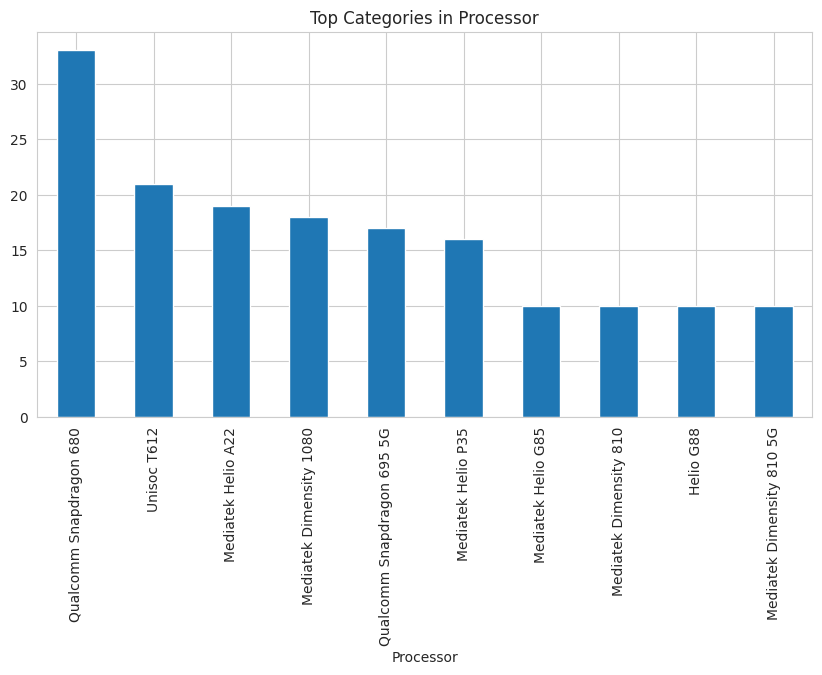

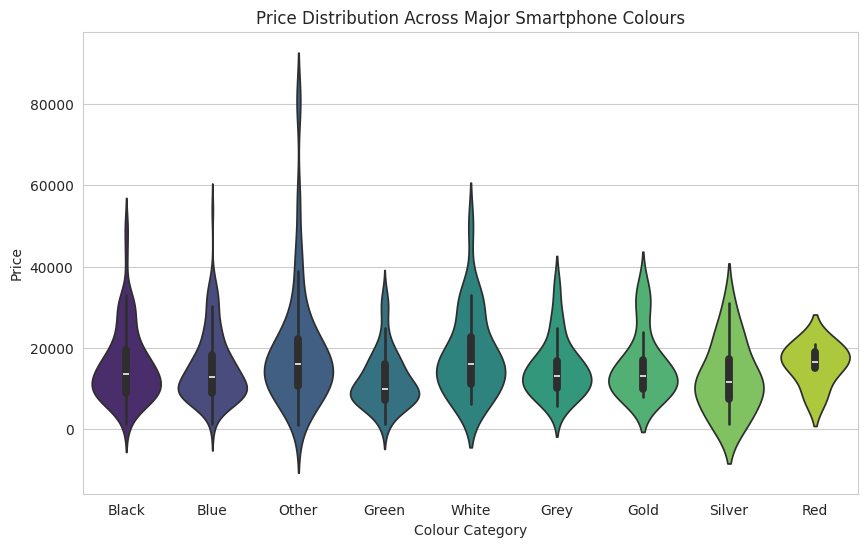

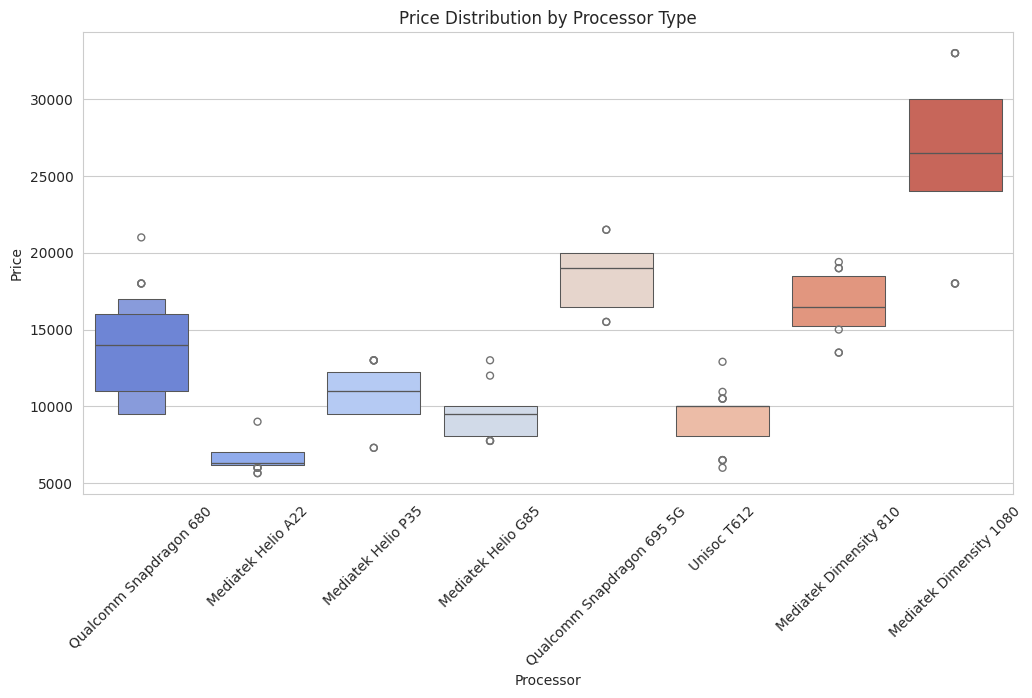

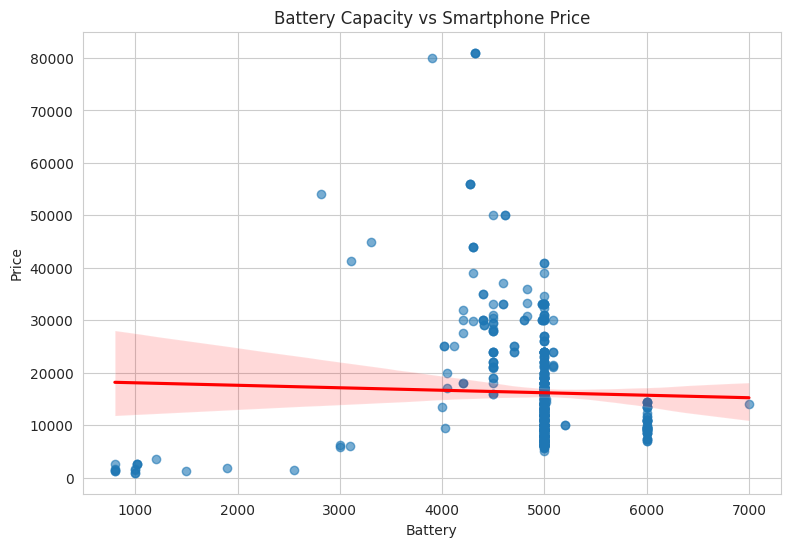

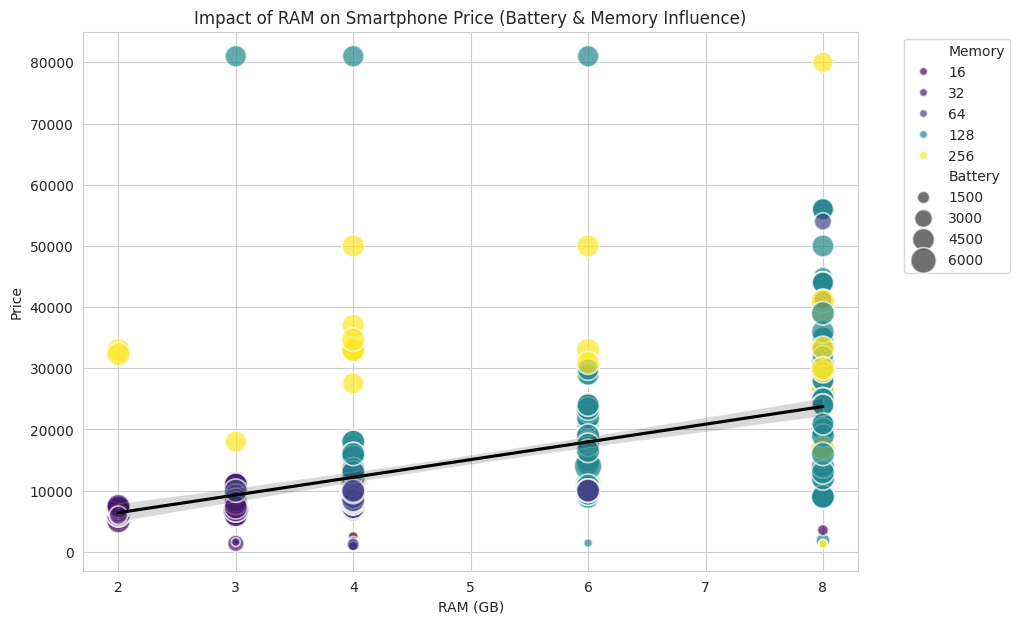


MODEL PERFORMANCE COMPARISON

               Model          MAE         RMSE        R2
3  Gradient Boosting  1759.673547  4177.380297  0.873389
2      Random Forest  1852.681843  4833.347430  0.830504
1      Decision Tree  1996.756284  5076.927528  0.812990
0  Linear Regression  4445.845428  8936.295865  0.420600


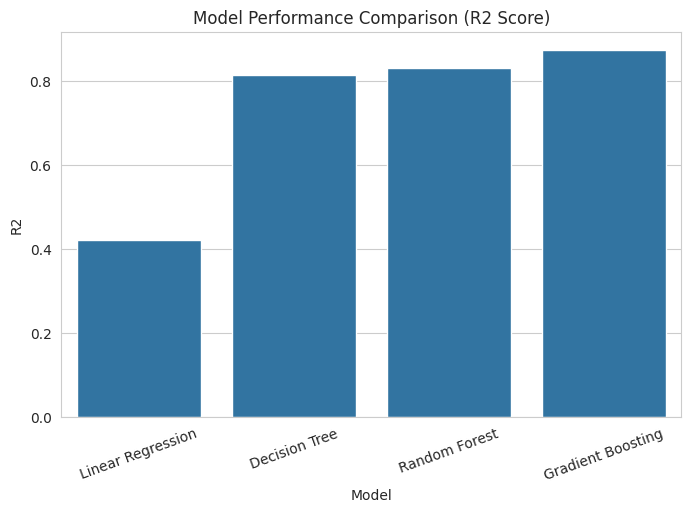


Best Model: Gradient Boosting


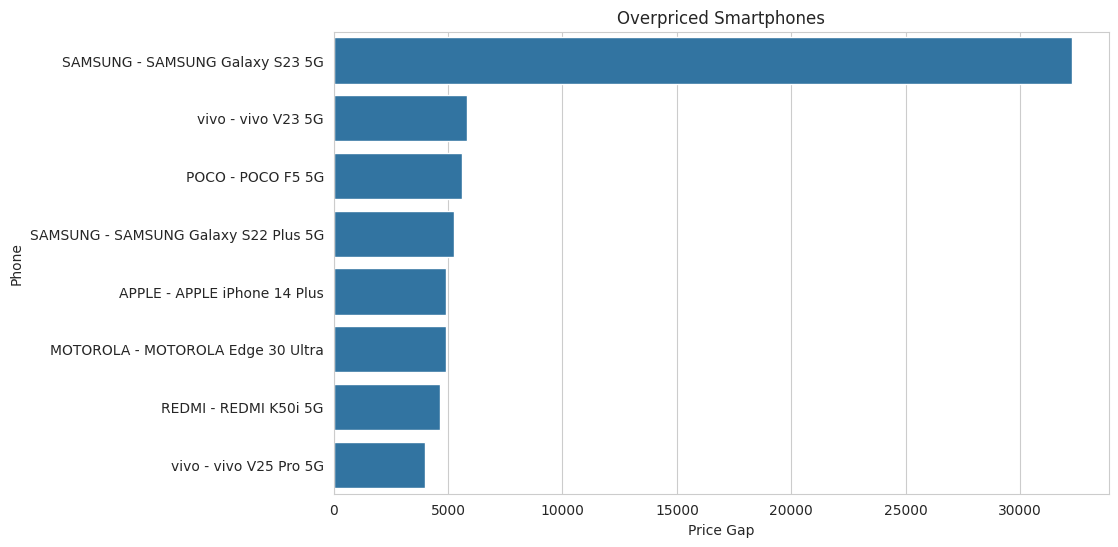

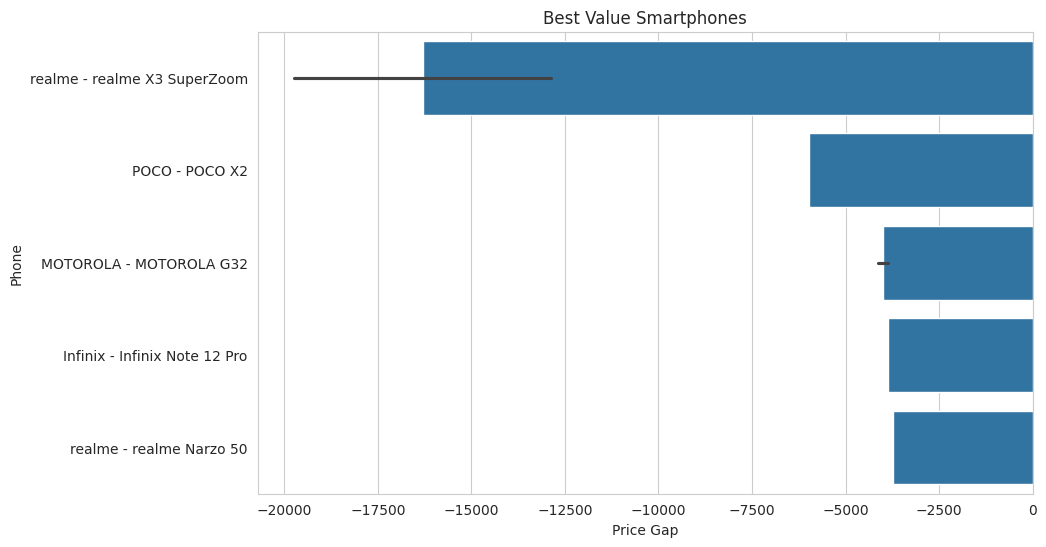

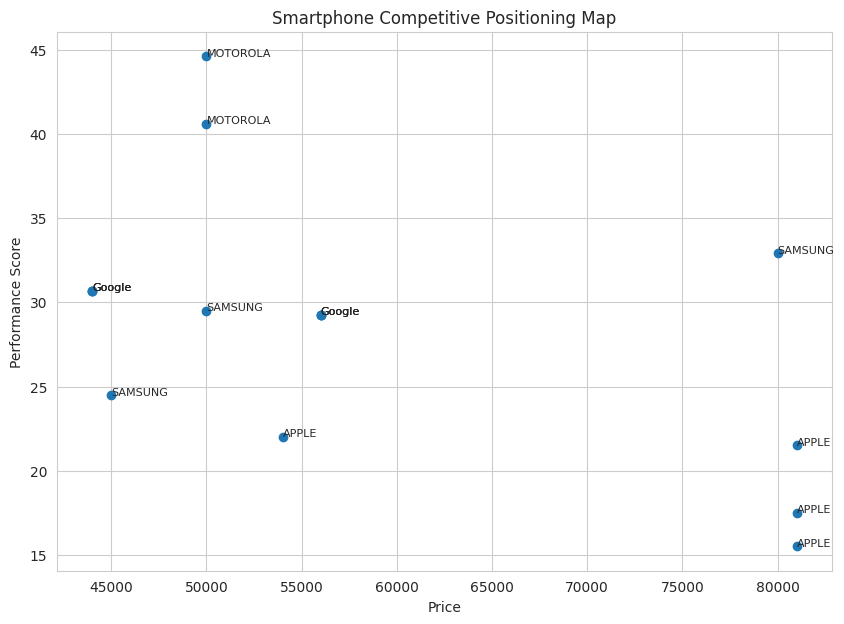

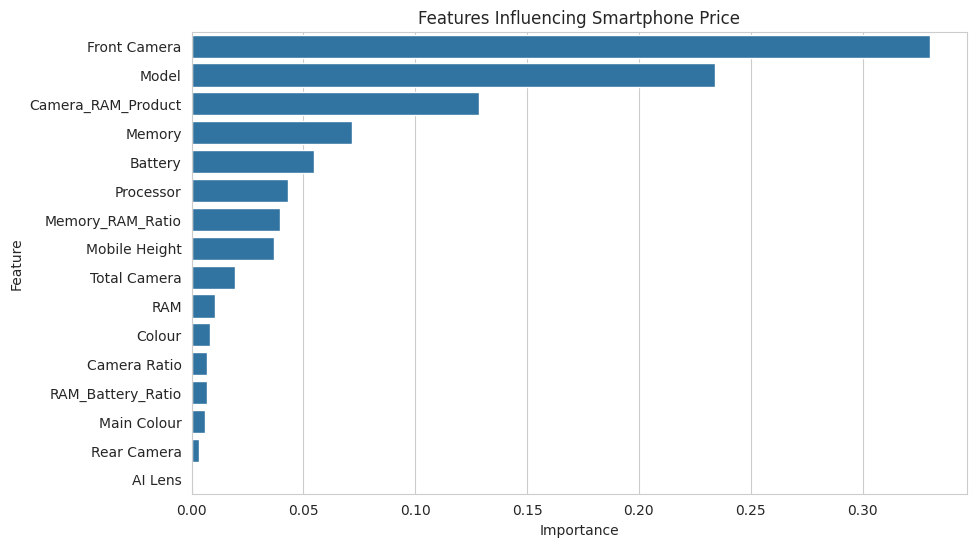

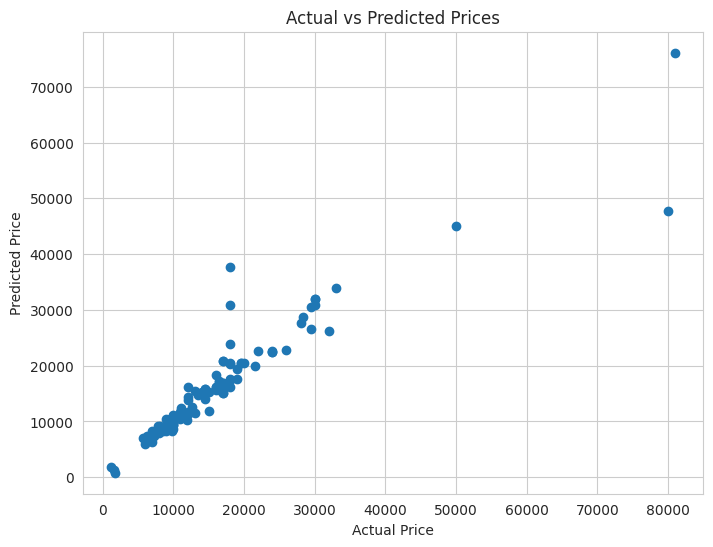


STRATEGIC BUSINESS RECOMMENDATIONS

1. Focus on RAM and Processor Improvements
------------------------------------------
The feature importance analysis shows that RAM and processor capability
are among the strongest factors influencing smartphone price.

Recommendation:
The company should prioritize increasing RAM capacity and improving
processor performance in mid-range devices to justify higher pricing
and improve market competitiveness.


2. Strengthen Camera Capabilities for Premium Segments
------------------------------------------------------
Camera resolution strongly influences consumer perception of quality
and plays a major role in premium smartphone pricing.

Recommendation:
Invest in higher-quality camera sensors and computational photography
features to compete with flagship devices from Apple, Samsung, and Google.


3. Introduce High-Performance Phones in Mid-Range Price Segments
----------------------------------------------------------------
The competitive position

In [ ]:

# 1 IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


# ==========================================================
# 2 LOAD DATASET
# ==========================================================

df = pd.read_excel("Processed_Flipdata.xlsx")

print("Dataset Shape:", df.shape)
print(df.head())

# Save original dataset for insights
original_df = df.copy()

print("\nDataset Info")
print(df.info())

print("\nDataset Description")
print(df.describe())

# ==========================================================
# 3 FIX COLUMN NAMES
# ==========================================================

df.rename(columns={
    "Prize":"Price",
    "Battery_":"Battery",
    "Processor_":"Processor"
}, inplace=True)

if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

    # ==========================================================
# CREATE MAIN COLOUR CATEGORY
# ==========================================================

def simplify_colour(col):

    col = col.lower()

    if "black" in col:
        return "Black"

    elif "blue" in col:
        return "Blue"

    elif "white" in col:
        return "White"

    elif "red" in col:
        return "Red"

    elif "green" in col:
        return "Green"

    elif "gold" in col:
        return "Gold"

    elif "silver" in col:
        return "Silver"

    elif "gray" in col or "grey" in col:
        return "Grey"

    else:
        return "Other"


df["Main Colour"] = df["Colour"].apply(simplify_colour)


# ==========================================================
# 4 CLEAN CAMERA COLUMNS
# ==========================================================

df["Rear Camera"] = df["Rear Camera"].str.replace("MP","").astype(int)
df["Front Camera"] = df["Front Camera"].str.replace("MP","").astype(int)


# ==========================================================
# 5 MISSING VALUES CHECK
# ==========================================================

print("\nMissing Values\n", df.isnull().sum())


# ==========================================================
# 6 IQR OUTLIER ANALYSIS
# ==========================================================

num_cols = df.select_dtypes(include=np.number).columns

print("\nIQR OUTLIER ANALYSIS\n")

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    if len(outliers) <= 2:
        df = df[(df[col] >= lower) & (df[col] <= upper)]
        print(col, "→ removed", len(outliers), "outliers")
    else:
        print(col, "→ many outliers:", len(outliers), "kept")


# ==========================================================
# 7 UNIVARIATE ANALYSIS (ALL FEATURES)
# ==========================================================

numeric_features = [
    "Price","RAM","Memory","Battery",
    "Rear Camera","Front Camera",
    "Mobile Height","AI Lens"
]

for col in numeric_features:

    plt.figure(figsize=(8,5))
    sns.histplot(df[col],bins=30,kde=True)
    plt.title(f"{col} Distribution")
    plt.show()


# CATEGORICAL DISTRIBUTION

categorical_features = ["Model","Colour","Processor"]

for col in categorical_features:

    plt.figure(figsize=(10,5))
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Top Categories in {col}")
    plt.show()



# ==========================================================
# 8 BIVARIATE VISUAL ANALYSIS
# ==========================================================



# ----------------------------------------------------------
# PRICE DISTRIBUTION BY MAIN COLOUR
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

sns.violinplot(
    x="Main Colour",
    y="Price",
    data=df,
    palette="viridis",
    order=df["Main Colour"].value_counts().index
)

plt.title("Price Distribution Across Major Smartphone Colours")
plt.xlabel("Colour Category")
plt.ylabel("Price")

plt.show()



# ----------------------------------------------------------
# PRICE DISTRIBUTION BY PROCESSOR (BOXEN PLOT)
# ----------------------------------------------------------

top_processors = df["Processor"].value_counts().head(8).index

plt.figure(figsize=(12,6))

sns.boxenplot(
    x="Processor",
    y="Price",
    data=df[df["Processor"].isin(top_processors)],
    palette="coolwarm"
)

plt.title("Price Distribution by Processor Type")
plt.xticks(rotation=45)

plt.show()



# ----------------------------------------------------------
# BATTERY VS PRICE (REGRESSION SCATTER)
# ----------------------------------------------------------

plt.figure(figsize=(9,6))

sns.regplot(
    x="Battery",
    y="Price",
    data=df,
    scatter_kws={"alpha":0.6},
    line_kws={"color":"red"}
)

plt.title("Battery Capacity vs Smartphone Price")

plt.show()



# ----------------------------------------------------------
# 9 RAM VS PRICE WITH MEMORY & BATTERY (MULTIVARIATE)
# ----------------------------------------------------------

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="RAM",
    y="Price",
    size="Battery",
    hue="Memory",
    sizes=(40,400),
    palette="viridis",
    alpha=0.7
)

sns.regplot(
    data=df,
    x="RAM",
    y="Price",
    scatter=False,
    color="black"
)

plt.title("Impact of RAM on Smartphone Price (Battery & Memory Influence)")
plt.xlabel("RAM (GB)")
plt.ylabel("Price")

plt.legend(bbox_to_anchor=(1.05,1))

plt.show()

# ==========================================================
# 10 FEATURE ENGINEERING
# ==========================================================

df["Total Camera"] = df["Rear Camera"] + df["Front Camera"]

df["Camera Ratio"] = df["Rear Camera"] / (df["Front Camera"] + 1)

df["RAM_Battery_Ratio"] = df["RAM"] / df["Battery"]

df["Memory_RAM_Ratio"] = df["Memory"] / (df["RAM"] + 1)

df["Camera_RAM_Product"] = df["Total Camera"] * df["RAM"]


# ==========================================================
# 11 ENCODING CATEGORICAL DATA
# ==========================================================

cat_cols = df.select_dtypes(include="object").columns

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])


# ==========================================================
# 12 FEATURE TARGET SPLIT
# ==========================================================

X = df.drop("Price", axis=1)
y = df["Price"]


# ==========================================================
# 13 STANDARDIZATION
# ==========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


# ==========================================================
# 14 TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================================
# 15 MODEL TRAINING AND COMPARISON
# ==========================================================

models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=8,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}


results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


results_df = pd.DataFrame(results)

print("\nMODEL PERFORMANCE COMPARISON\n")
print(results_df.sort_values(by="R2", ascending=False))

# ==========================================================
# 16 MODEL COMPARISON VISUALIZATION
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="R2",
    data=results_df
)

plt.title("Model Performance Comparison (R2 Score)")
plt.xticks(rotation=20)

plt.show()

# ==========================================================
# 17 SELECT BEST MODEL
# ==========================================================

best_model_name = results_df.sort_values(
    by="R2",
    ascending=False
).iloc[0]["Model"]

best_model = models[best_model_name]

print("\nBest Model:", best_model_name)


# ==========================================================
# 18 BUSINESS INSIGHTS
# ==========================================================

insight_df = original_df.copy()

insight_df.rename(columns={
    "Prize":"Price",
    "Battery_":"Battery",
    "Processor_":"Processor"
}, inplace=True)

insight_df["Rear Camera"] = insight_df["Rear Camera"].str.replace("MP","").astype(int)
insight_df["Front Camera"] = insight_df["Front Camera"].str.replace("MP","").astype(int)

if "Unnamed: 0" in insight_df.columns:
    insight_df.drop("Unnamed: 0", axis=1, inplace=True)

X_all_scaled = scaler.transform(X)
pred_all = model.predict(X_all_scaled)

insight_df["Predicted Price"] = pred_all
insight_df["Price Gap"] = insight_df["Price"] - insight_df["Predicted Price"]

insight_df["Brand"] = insight_df["Model"].str.split().str[0]
insight_df["Phone"] = insight_df["Brand"] + " - " + insight_df["Model"]


# ==========================================================
# 19 OVERPRICED PHONES
# ==========================================================

overpriced = insight_df.sort_values("Price Gap", ascending=False).head(8)

plt.figure(figsize=(10,6))
sns.barplot(x="Price Gap",y="Phone",data=overpriced)
plt.title("Overpriced Smartphones")
plt.show()


# ==========================================================
# 20 BEST VALUE PHONES
# ==========================================================

value = insight_df.sort_values("Price Gap").head(8)

plt.figure(figsize=(10,6))
sns.barplot(x="Price Gap",y="Phone",data=value)
plt.title("Best Value Smartphones")
plt.show()


# ==========================================================
# 21 COMPETITIVE POSITION MAP
# ==========================================================

insight_df["Performance Score"] = (
    insight_df["RAM"]*2 +
    insight_df["Memory"]/32 +
    insight_df["Rear Camera"]/10 +
    insight_df["Battery"]/1000
)

top_competitors = insight_df.sort_values("Price",ascending=False).head(15)

plt.figure(figsize=(10,7))

plt.scatter(
    top_competitors["Price"],
    top_competitors["Performance Score"]
)

for i,row in top_competitors.iterrows():
    plt.text(row["Price"],row["Performance Score"],row["Brand"],fontsize=8)

plt.xlabel("Price")
plt.ylabel("Performance Score")
plt.title("Smartphone Competitive Positioning Map")

plt.show()


# ==========================================================
# 22 FEATURE IMPORTANCE
# ==========================================================

if hasattr(best_model, "feature_importances_"):

    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(10,6))

    sns.barplot(
        x="Importance",
        y="Feature",
        data=feature_importance
    )

    plt.title("Features Influencing Smartphone Price")

    plt.show()

# ==========================================================
# 23 ACTUAL VS PREDICTED
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(y_test,pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()


# ==========================================================
# 24 BUSINESS RECOMMENDATIONS
# ==========================================================

print("\n==============================")
print("STRATEGIC BUSINESS RECOMMENDATIONS")
print("==============================")

print("""
1. Focus on RAM and Processor Improvements
------------------------------------------
The feature importance analysis shows that RAM and processor capability
are among the strongest factors influencing smartphone price.

Recommendation:
The company should prioritize increasing RAM capacity and improving
processor performance in mid-range devices to justify higher pricing
and improve market competitiveness.
""")


print("""
2. Strengthen Camera Capabilities for Premium Segments
------------------------------------------------------
Camera resolution strongly influences consumer perception of quality
and plays a major role in premium smartphone pricing.

Recommendation:
Invest in higher-quality camera sensors and computational photography
features to compete with flagship devices from Apple, Samsung, and Google.
""")


print("""
3. Introduce High-Performance Phones in Mid-Range Price Segments
----------------------------------------------------------------
The competitive positioning map reveals gaps where few smartphones
offer high performance at moderate prices.

Recommendation:
Launch smartphones that combine strong RAM, processor, and camera
features while keeping prices slightly lower than premium competitors.
This can attract value-conscious consumers.
""")


print("""
4. Use Competitive Pricing to Challenge Overpriced Devices
----------------------------------------------------------
Some smartphones in the dataset appear overpriced relative to their
hardware specifications.

Recommendation:
The company can introduce devices with similar specifications but
more competitive pricing to capture customers from premium brands.
""")


print("""
5. Promote Battery Life as a Key Differentiator
-----------------------------------------------
Battery capacity significantly influences user satisfaction, especially
for users who prioritize long device usage.

Recommendation:
Marketing campaigns should emphasize long battery life and fast charging
capabilities as key selling points.
""")


print("""
6. Optimize Feature Bundles Instead of Single Upgrades
------------------------------------------------------
The analysis suggests that smartphones priced in the premium segment
typically combine multiple strong features such as RAM, camera quality,
and processor power.

Recommendation:
Instead of focusing on a single specification improvement, the company
should design balanced feature bundles that deliver overall performance.
""")


print("""
7. Target Underserved Price Segments
------------------------------------
Market price distribution analysis shows heavy competition in budget
segments and fewer devices in higher mid-range segments.

Recommendation:
Develop products positioned between mid-range and premium devices
to capture customers seeking flagship-like performance at lower prices.
""")

# ==========================================================
# 23 SAVE MODEL
# ==========================================================

joblib.dump(model,"mobile_price_model.pkl")

print("\nModel Saved Successfully")